# Import Libs

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import logging
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch import optim
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from tqdm import tqdm

from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.optim import AdamW
from utils import SklearnWrapper, verify_scaling
from utils.paths import CHECKPOINTS_DIR
from pypfopt import risk_models, expected_returns, plotting, EfficientFrontier

In [2]:
from config import *
from entities import *
from strategies import *
from datasets import *
from engine import Engine
from models import DiffusionTransformer
from frameworks import Diffusion

# Setup

## Config

In [3]:
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

In [4]:
cfg = TrainConfig(
    batch_size=32,
    window_size=128,
    steps_to_sim=4,
    num_sims=100,
    epochs=300,
    optimizer=OptimizerConfig(lr=2e-4)
)

print(cfg)

TrainConfig(batch_size=32, window_size=128, steps_to_sim=4, num_sims=100, epochs=300, device='cuda', optimizer=OptimizerConfig(lr=0.0002, weight_decay=1e-06, betas=(0.9, 0.999), eps=1e-08), scheduler=SchedulerConfig(use_scheduler=False, type='cosine', eta_min=1e-06), ddpm=DDPMConfig(noise_steps=1000, beta_start=0.0001, beta_end=0.02, schedule='cosine', d_model=128, n_heads=4, n_layers=4, max_t=128))


# Data

## Load assets (T, A)

In [5]:
symbols = ['AAPL', 'TSLA', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'GOOG', 'META', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'AMD', 'CSCO']
freq = "1d"
# Basket
basket = Basket(symbols=symbols)
basket.load_all_assets(freq=freq)

DEBUG:entities.basket:Initialized Asset Basket: ['AAPL', 'TSLA', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'GOOG', 'META', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'AMD', 'CSCO'] with 0 assets which loaded.
INFO:entities.basket:Starting batch load for 14 symbols...
DEBUG:entities.basket:Attempting to load AAPL...
DEBUG:entities.asset:Initialized Asset: AAPL with 2724 rows.
INFO:entities.basket:Successfully loaded AAPL (2724 rows).
DEBUG:entities.basket:Attempting to load TSLA...
DEBUG:entities.asset:Initialized Asset: TSLA with 2760 rows.
INFO:entities.basket:Successfully loaded TSLA (2760 rows).
DEBUG:entities.basket:Attempting to load MSFT...
DEBUG:entities.asset:Initialized Asset: MSFT with 2724 rows.
INFO:entities.basket:Successfully loaded MSFT (2724 rows).
DEBUG:entities.basket:Attempting to load NVDA...
DEBUG:entities.asset:Initialized Asset: NVDA with 2724 rows.
INFO:entities.basket:Successfully loaded NVDA (2724 rows).
DEBUG:entities.basket:Attempting to load GOOGL...
DEBUG:entities.asset:Initia

## Feature (C)

### Align Data (Align C)
$\text{Align}(FT) \to FT_{\text{aligned}}$
1. We must find Joint Distribution $FT_{\text{date\ A}} \cap FT_{\text{date\ B}}$

2. Other plan

In [6]:
targets = ["Close"]
print(basket.get_unique_features())

['Close', 'High', 'Low', 'Open', 'Volume']


In [7]:
print(f"Basket data shape: {basket.data.shape}")

strategy = IntersectionStrategy()
basket.align(strategy)

print(f"Basket data shape: {basket.data.shape}")

Basket data shape: (2760, 70)


INFO:strategies.concrete:Aligned: 14 orig -> 14 clean assets -> 1464 rows
DEBUG:entities.basket:Aligned data shape: (1464, 70)
INFO:entities.basket:Assets updated in-place to aligned index (Length: 1464)


Basket data shape: (1464, 70)


### Select Features for norm to Returns 
$ \|FT\| \to FT_{\text{returns}} $

In [8]:
basket.to_returns(features=targets, log=True, keep=False)

print(basket.get_unique_features())
basket.data.head(5)

DEBUG:entities.asset:AAPL converted to Returns (log=True)
DEBUG:entities.asset:TSLA converted to Returns (log=True)
DEBUG:entities.asset:MSFT converted to Returns (log=True)
DEBUG:entities.asset:NVDA converted to Returns (log=True)
DEBUG:entities.asset:GOOGL converted to Returns (log=True)
DEBUG:entities.asset:AMZN converted to Returns (log=True)
DEBUG:entities.asset:GOOG converted to Returns (log=True)
DEBUG:entities.asset:META converted to Returns (log=True)
DEBUG:entities.asset:AVGO converted to Returns (log=True)
DEBUG:entities.asset:ORCL converted to Returns (log=True)
DEBUG:entities.asset:CRM converted to Returns (log=True)
DEBUG:entities.asset:ADBE converted to Returns (log=True)
DEBUG:entities.asset:AMD converted to Returns (log=True)
DEBUG:entities.asset:CSCO converted to Returns (log=True)


['Close (Log_Returns)', 'High', 'Low', 'Open', 'Volume']


AAPL                                                       \
                 High        Low       Open     Volume Close (Log_Returns)   
Date                                                                         
2020-01-03  72.594055  71.608685  71.765667  146322800           -0.009770   
2020-01-06  72.444344  70.703034  70.954210  118387200            0.007937   
2020-01-07  72.671341  71.845369  72.415337  108872000           -0.004715   
2020-01-08  73.526310  71.768094  71.768094  132079200            0.015958   
2020-01-09  74.972955  73.951358  74.202527  170108400            0.021018   

                 TSLA                                                       \
                 High        Low       Open     Volume Close (Log_Returns)   
Date                                                                         
2020-01-03  30.266666  29.128000  29.366667  266677500            0.029203   
2020-01-06  30.104000  29.333332  29.364668  151995000            0.019072   
2020-01-07  31.441999  30.224001  30.760000  268231500            0.038067   
2020-01-08  33.232666  31.215334  31.580000  467164500            0.048033   
2020-01-09  33.253334  31.524668  33.139999  426606000           -0.022189   

            ...        AMD                                  \
            ...       High        Low       Open    Volume   
Date        ...                                              
2020-01-03  ...  49.389999  47.540001  48.029999  73127400   
2020-01-06  ...  48.860001  47.860001  48.020000  47934900   
2020-01-07  ...  49.389999  48.040001  49.349998  58061400   
2020-01-08  ...  48.299999  47.139999  47.849998  53767000   
2020-01-09  ...  49.959999  48.389999  48.939999  76512800   

                                     CSCO                                  \
           Close (Log_Returns)       High        Low       Open    Volume   
Date                                                                        
2020-01-03           -0.010236  40.453623  39.899004  40.260347  15577400   
2020-01-06           -0.004330  40.184715  39.504044  39.613288  22183600   
2020-01-07           -0.002897  40.100678  39.579670  40.100678  16501900   
2020-01-08           -0.008743  40.159507  39.335982  39.470435  25175900   
2020-01-09            0.023555  40.235133  39.554462  40.159503  18203600   

                                
           Close (Log_Returns)  
Date                            
2020-01-03           -0.016450  
2020-01-06            0.003563  
2020-01-07           -0.006507  
2020-01-08            0.000632  
2020-01-09           -0.004218  

[5 rows x 70 columns]

## Tensor (T, A, C) & DataLoader (N, T, A, C)
N means batch size

### Select Feature to tensor
* std, mean, max require dim = Time (T)
* cov, corr require dim = Assets, Time (A, T)

In [9]:
targets = ["Close (Log_Returns)"]
basket_tensor = basket.to_tensor(features=targets)
print(f"Basket Tensor Shape: {basket_tensor.shape}")

DEBUG:entities.asset:Asset: AAPL is using cuda device.
DEBUG:entities.asset:Asset: TSLA is using cuda device.
DEBUG:entities.asset:Asset: MSFT is using cuda device.
DEBUG:entities.asset:Asset: NVDA is using cuda device.
DEBUG:entities.asset:Asset: GOOGL is using cuda device.
DEBUG:entities.asset:Asset: AMZN is using cuda device.
DEBUG:entities.asset:Asset: GOOG is using cuda device.
DEBUG:entities.asset:Asset: META is using cuda device.
DEBUG:entities.asset:Asset: AVGO is using cuda device.
DEBUG:entities.asset:Asset: ORCL is using cuda device.
DEBUG:entities.asset:Asset: CRM is using cuda device.
DEBUG:entities.asset:Asset: ADBE is using cuda device.
DEBUG:entities.asset:Asset: AMD is using cuda device.
DEBUG:entities.asset:Asset: CSCO is using cuda device.


Basket Tensor Shape: torch.Size([1463, 14, 1])


### Define Ratios Dataset

In [10]:
market_dataset = TensorDataset(basket_tensor)

ratios = [0.8, 0.1, 0.1]
total_count = len(market_dataset)
train_count = int(total_count * ratios[0])
val_count = int(total_count * ratios[1])
test_count = total_count - train_count - val_count

print(f"Market ds - Total: {total_count}\nTrain:\t{train_count}\nVal:\t{val_count}\nTest:\t{test_count}")

Market ds - Total: 1463
Train:	1170
Val:	146
Test:	147


### Scale Dataset

In [11]:
scaler = MinMaxScaler(feature_range=(-1, 1))
# scaler = StandardScaler()

train_part = basket_tensor[:train_count].cpu().numpy()
scaler.fit(train_part.reshape(-1, 1))

basket_scaled_np = scaler.transform(basket_tensor.cpu().numpy().reshape(-1, 1))
basket_scaled_tensor = torch.from_numpy(basket_scaled_np.reshape(basket_tensor.shape)).float()

verify_scaling(basket_scaled_tensor)
print(f"train_ds_scaled shape: {basket_scaled_tensor.shape}")

--- Global Stats ---
Max: 1.2813
Min: -1.0000
Mean: 0.1431
Std: 0.0979
train_ds_scaled shape: torch.Size([1463, 14, 1])


### Sliding Window Tensor [N, T, A, C]
N = Num of windows

In [12]:
basket_scaled_tensor = torch.from_numpy(sliding_window_view(basket_scaled_tensor.cpu(), window_shape=cfg.window_size, axis=0))
print(f"Org windowing basket shape: {basket_scaled_tensor.shape}")

basket_scaled_tensor = basket_scaled_tensor.permute(0,3,1,2)
print(f"New windowing basket shape: {basket_scaled_tensor.shape}")

verify_scaling(basket_scaled_tensor)

Org windowing basket shape: torch.Size([1336, 14, 1, 128])
New windowing basket shape: torch.Size([1336, 128, 14, 1])
--- Global Stats ---
Max: 1.2813
Min: -1.0000
Mean: 0.1428
Std: 0.0953


/tmp/ipykernel_27678/2971894030.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647429097/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  basket_scaled_tensor = torch.from_numpy(sliding_window_view(basket_scaled_tensor.cpu(), window_shape=cfg.window_size, axis=0))


### Split Dataset
Have 2 Versions!
1. Sequence
2. Random Split

In [13]:
end_train = train_count
end_val = train_count + val_count

train_ds = TensorDataset(basket_scaled_tensor[:end_train])
val_ds = TensorDataset(basket_scaled_tensor[:end_val])
test_ds = TensorDataset(basket_scaled_tensor[end_val:])

In [14]:
# full_ds = TensorDataset(basket_scaled_tensor)

# train_ds, val_ds, test_ds = random_split(
#     full_ds, 
#     [train_count, val_count, test_count],
#     generator=torch.Generator().manual_seed(42) 
# )

### Dataloader

In [15]:
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

batch = next(iter(train_loader)) # Batch: X_t only // for future if u need more data add to batch.
X_train = batch[0]
print(f"Num of Batchs in train dataloader: {len(train_loader)}")
print(f"Batch size: {len(batch)}")
print(f"X train shape: {X_train.shape}")

Num of Batchs in train dataloader: 37
Batch size: 1
X train shape: torch.Size([32, 128, 14, 1])


## Model

In [16]:
window_size = X_train.shape[1]       # T
n_assets = X_train.shape[2]        # A
n_features = X_train.shape[3]      # FT
total_inp_dim = n_assets * n_features # C = A * FT (Flatten)

print(f"Running on: {cfg.device}")
print(f"Input Dimension (Channels): {total_inp_dim}")

Running on: cuda
Input Dimension (Channels): 14


In [17]:
diffusion = Diffusion(
    noise_steps=cfg.ddpm.noise_steps,
    beta_start=cfg.ddpm.beta_start,
    beta_end=cfg.ddpm.beta_end,
    schedule=cfg.scheduler.type,
    device=cfg.device
)

DEBUG:frameworks.ddpm:Diffusion is using cosine schedule.


In [18]:
model = DiffusionTransformer(
    features_in=total_inp_dim, 
    d_model=cfg.ddpm.d_model,                  
    nhead=cfg.ddpm.n_heads,
    num_layers=cfg.ddpm.n_layers,
    max_len=window_size    
).to(cfg.device)

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [19]:
optimizer = AdamW(model.parameters(), lr=cfg.optimizer.lr, weight_decay=cfg.optimizer.weight_decay)

In [20]:
engine = Engine(
    model=model,
    diffusion=diffusion,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    device=cfg.device,
    scaler=scaler
)

## Training

In [21]:
engine.fit(epochs=cfg.epochs, save_dir=CHECKPOINTS_DIR)

INFO:engine.trainer:Engine started Training for 300 epochs on cuda...
Epoch 300/300: 100%|██████████| 37/37 [00:02<00:00, 13.28it/s, loss=0.0730]
INFO:engine.trainer:Epoch 300 | Train Loss: 0.053668 | Val Loss: 0.051776
INFO:engine.trainer:Saved Best Model at /home/narodom.y@FUSION.LAB/research/results/checkpoints/best_model.pt


## Testing

### X_test Scaled

In [22]:
batch = next(iter(test_loader))
X_test = batch[0] 
print(f"X_test: {X_test.shape}")

# pick 1 window
X_test = X_test[0]
verify_scaling(X_test)
print(f"X_test: {X_test.shape}")

X_test: torch.Size([20, 128, 14, 1])
--- Global Stats ---
Max: 1.2813
Min: -0.4328
Mean: 0.1489
Std: 0.1001
X_test: torch.Size([128, 14, 1])


In [23]:
steps_to_sim = cfg.steps_to_sim
X_test_context = X_test[:-steps_to_sim,:,:]
y_test = X_test[-steps_to_sim:,:,:]
print(f"X_test_context: {X_test_context.shape}")
print(f"y_test: {y_test.shape}")

X_test_context: torch.Size([124, 14, 1])
y_test: torch.Size([4, 14, 1])


In [24]:
sim = engine.simulate(X_test_context, steps=steps_to_sim, extend=True)
sim = sim[-steps_to_sim:, :, :]
verify_scaling(sim)
print(f"Type of simulation: {type(sim)}")
print(f"simulation: {sim.shape}")

INFO:engine.trainer:Simulating... (Masking last 4 steps)
In-painting: 1000it [00:04, 238.36it/s]

--- Global Stats ---
Max: 0.2720
Min: 0.0894
Mean: 0.1522
Std: 0.0340
Type of simulation: <class 'numpy.ndarray'>
simulation: (4, 14, 1)


In [25]:
def inverse_scale(x: torch.Tensor, scaler):
    if torch.is_tensor(x):
        x_np = x.detach().cpu().numpy()
    else:
        x_np = x
        
    org_shape = x_np.shape
    flat_x = x_np.reshape(-1, 1)

    inverse_flat = scaler.inverse_transform(flat_x)
    inverse_x = inverse_flat.reshape(org_shape)

    return torch.from_numpy(inverse_x)

### Inverse Scale

In [26]:
X_test = inverse_scale(X_test, scaler)
X_test_context = inverse_scale(X_test_context, scaler)
y_test = inverse_scale(y_test, scaler)
sim = inverse_scale(torch.from_numpy(sim), scaler)

verify_scaling(X_test)
verify_scaling(X_test_context)
verify_scaling(y_test)
verify_scaling(sim)

print(f"X_test shape: {X_test.shape}")
print(f"X_test shape: {X_test_context.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"sim shape: {sim.shape}")

--- Global Stats ---
Max: 0.3071
Min: -0.1538
Mean: 0.0026
Std: 0.0269
--- Global Stats ---
Max: 0.3071
Min: -0.1538
Mean: 0.0026
Std: 0.0272
--- Global Stats ---
Max: 0.0394
Min: -0.0336
Mean: 0.0014
Std: 0.0140
--- Global Stats ---
Max: 0.0357
Min: -0.0134
Mean: 0.0035
Std: 0.0092
X_test shape: torch.Size([128, 14, 1])
X_test shape: torch.Size([124, 14, 1])
y_test shape: torch.Size([4, 14, 1])
sim shape: torch.Size([4, 14, 1])


In [27]:
# X_test_smp = scaler.decode(X_test_smp)
# y_test_smp = scaler.decode(y_test_smp)
# sim = scaler.decode(torch.from_numpy(sim))

# verify_scaling(X_test_smp)
# verify_scaling(y_test_smp)
# verify_scaling(sim)

### Comparision just 1 sim

In [28]:
X_test_df = pd.DataFrame(X_test.detach().cpu().numpy().squeeze(-1))
y_test_df = pd.DataFrame(y_test.detach().cpu().numpy().squeeze(-1))
sim_df = pd.DataFrame(sim.squeeze(-1))

print(f"X_test_smp_df: {type(X_test_df.shape)}, {X_test_df.shape}")
print(f"y_test_smp_df: {type(y_test_df.shape)}, {y_test_df.shape}")
print(f"sim_df: {type(sim_df.shape)}, {sim_df.shape}")

X_test_smp_df: <class 'tuple'>, (128, 14)
y_test_smp_df: <class 'tuple'>, (4, 14)
sim_df: <class 'tuple'>, (4, 14)


In [29]:
mu_ai = expected_returns.mean_historical_return(sim_df)

mu_real = expected_returns.mean_historical_return(y_test_df)

comparison = pd.DataFrame({
    'AI Prediction': mu_ai,
    'Actual (Real)': mu_real,
    'Diff (Error)': mu_ai - mu_real 
})

print(comparison)

    AI Prediction  Actual (Real)  Diff (Error)
0    2.092871e+56  -1.000000e+00  2.092871e+56
1   -1.000000e+00  -9.999999e-01 -1.276569e-07
2   -1.000000e+00  -1.000000e+00  0.000000e+00
3   -1.000000e+00   2.159137e+08 -2.159137e+08
4    3.292405e+51   1.819004e+32  3.292405e+51
5    2.493907e+43  -1.000000e+00  2.493907e+43
6    9.425972e+47   3.039151e+43  9.425668e+47
7   -9.999999e-01   3.955688e+44 -3.955688e+44
8   -1.000000e+00   2.742970e+29 -2.742970e+29
9   -1.000000e+00  -3.348714e-01 -6.651286e-01
10  -1.000000e+00  -1.000000e+00  0.000000e+00
11   7.509560e+39   3.918850e+14  7.509560e+39
12   1.210430e+65   7.528857e+06  1.210430e+65
13  -1.000000e+00  -1.000000e+00  0.000000e+00


/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/pypfopt/risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(


<Axes: >

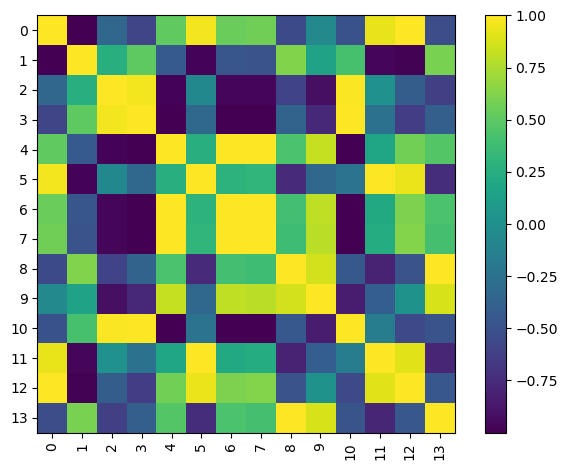

In [30]:
sim_cov = risk_models.sample_cov(sim_df)
plotting.plot_covariance(sim_cov, plot_correlation=True)

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/pypfopt/risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(


<Axes: >

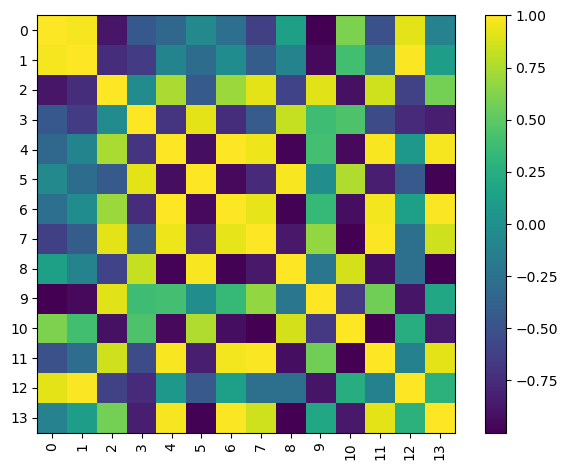

In [31]:
y_test_cov = risk_models.sample_cov(y_test_df)
plotting.plot_covariance(y_test_cov, plot_correlation=True)

In [32]:
cov = risk_models.CovarianceShrinkage(sim_df).ledoit_wolf() # Or .oracle()
cov

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,3231.365967,-226.300446,-41.391994,-1639.868286,693.326111,177.354294,248.058197,4607.813477,-178.046982,-24.371000,-753.244385,809.594666,259.292175,-1430.674194
1,-226.300446,2634.493896,10.340746,478.386902,-196.446564,-61.191998,-71.399193,-1337.648804,68.358322,21.700239,211.892853,-281.609680,-86.517143,554.473694
2,-41.391994,10.340746,2579.433838,489.309692,-237.999466,-2.300306,-79.183655,-1409.996948,-34.782684,-70.852837,266.765076,1.695340,-19.135193,-307.275543
3,-1639.868286,478.386902,489.309692,14456.843750,-5664.175293,-256.810333,-1905.085327,-34149.054688,-496.999084,-1412.980591,6320.496094,-924.116211,-696.416199,-4558.963379
4,693.326111,-196.446564,-237.999466,-5664.175293,5271.075195,94.561989,909.683411,16274.804688,284.660278,715.333923,-3031.653564,306.850677,299.658569,2571.683838
5,177.354294,-61.191998,-2.300306,-256.810333,94.561989,2608.367920,36.519955,705.795593,-67.472343,-38.999752,-99.042526,236.339386,66.831383,-554.677917
6,248.058197,-71.399193,-79.183655,-1905.085327,909.683411,36.519955,2863.278320,5470.589355,87.554024,233.317917,-1015.751587,125.865379,106.211250,796.573425
7,4607.813477,-1337.648804,-1409.996948,-34149.054688,16274.804688,705.795593,5470.589355,100583.757812,1480.562622,4103.300781,-18165.095703,2502.063965,1962.722778,13536.624023
8,-178.046982,68.358322,-34.782684,-496.999084,284.660278,-67.472343,87.554024,1480.562622,2714.361328,179.707687,-328.892151,-337.207611,-60.873367,1324.587646
9,-24.371000,21.700239,-70.852837,-1412.980591,715.333923,-38.999752,233.317917,4103.300781,179.707687,2832.842529,-808.217041,-224.242676,2.748977,1549.301514


### Monte Carlo (GenAI)

In [33]:
batch = next(iter(test_loader))

X_test = batch[0] 
verify_scaling(X_test)
print(f"X_test: {X_test.shape}")

X_test = X_test[0]
verify_scaling(X_test)
print(f"X_test: {X_test.shape}")

--- Global Stats ---
Max: 1.2813
Min: -0.4328
Mean: 0.1511
Std: 0.0913
X_test: torch.Size([20, 128, 14, 1])
--- Global Stats ---
Max: 1.2813
Min: -0.4328
Mean: 0.1489
Std: 0.1001
X_test: torch.Size([128, 14, 1])


In [34]:
cfg.steps_to_sim = 24

In [35]:
steps_to_sim = cfg.steps_to_sim
num_sims = cfg.num_sims
X_test_context = X_test[:-steps_to_sim,:,:]
y_test = X_test[-steps_to_sim:,:,:]

print(f"X_test_context: {X_test_context.shape}")
print(f"y_test: {y_test.shape}")

X_test_context: torch.Size([104, 14, 1])
y_test: torch.Size([24, 14, 1])


In [36]:
@torch.no_grad()
def monte_carlo_simulate(x_context, steps, engine, num_simulations=100):
    # engine.simulate() Require Shape [T, A, C] only
    results = []
    for i in range(num_simulations):
        sim_result = engine.simulate(
            x_context.to(engine.device), 
            steps=steps, 
            extend=True
        )
        results.append(torch.from_numpy(sim_result).cpu())
        
    mc_results_tensor = torch.stack(results)
    
    print(f"MC Finished! Result shape: {mc_results_tensor.shape}") # [N-Sim , T, A, C]
    return mc_results_tensor

In [37]:
genai_mc = monte_carlo_simulate(x_context=X_test_context, steps=steps_to_sim, engine=engine, num_simulations=num_sims)
print(f"GenAI MC: {genai_mc.shape}")

INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 236.83it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 240.39it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 238.49it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 236.61it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 235.85it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 236.22it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 237.50it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 236.67it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 236.01it/s]
INFO:engine.trainer:Simulating... (Masking last 24 steps)
In-painting: 1000it [00:04, 236.91it/s]
INFO:engine.trainer:

MC Finished! Result shape: torch.Size([100, 128, 14, 1])
GenAI MC: torch.Size([100, 128, 14, 1])


In [38]:
genai_mc = inverse_scale(genai_mc, scaler)

verify_scaling(genai_mc)

print(f"genai_mc shape: {genai_mc.shape}")

--- Global Stats ---
Max: 0.2256
Min: -0.3064
Mean: 0.0024
Std: 0.0257
genai_mc shape: torch.Size([100, 128, 14, 1])


### Monte Carlo (Statistic)

In [39]:
def gbm_monte_carlo_vectorized(hist_log_returns, steps, num_sims=100, dt=1.0):
    """
    Args: 
        hist_log_returns: Shape [Time, Agents] (เช่น [64, 14])
    Returns: 
        future_log_returns: Shape [Sims, Steps, Agents]
    """
    # 1. เช็ค Input ถ้ามาแบบ [64] (1D) ให้แก้เป็น [64, 1]
    if hist_log_returns.ndim == 1:
        hist_log_returns = hist_log_returns[:, np.newaxis]
    
    # ตอนนี้ shape เป็น [Time, Agents] แน่นอน
    n_agents = hist_log_returns.shape[1]

    # 2. คำนวณ Mu, Sigma แยกราย Agent (สำคัญมาก! ใช้ axis=0)
    # mu shape: [14]
    mu = np.mean(hist_log_returns, axis=0) 
    sigma = np.std(hist_log_returns, axis=0)

    # 3. Generate Noise (Z)
    # Shape: [Sims, Steps, Agents] -> [3, 8, 14]
    Z = np.random.normal(0, 1, (num_sims, steps, n_agents))

    # 4. คำนวณ GBM (ใช้ Broadcasting)
    # drift: [14] (จะถูกกระจายไปทุก Sim และ Step)
    drift_term = (mu - 0.5 * sigma**2) * dt
    
    # shock: [14] * [3, 8, 14] (คูณกันลงตัวพอดี)
    shock_term = sigma * np.sqrt(dt) * Z

    # Result Shape: [3, 8, 14]
    future_daily_log_returns = drift_term + shock_term
    
    return future_daily_log_returns

In [40]:
X_test = inverse_scale(X_test, scaler)
X_test_context = inverse_scale(X_test_context, scaler)
y_test = inverse_scale(y_test, scaler)

verify_scaling(X_test)
verify_scaling(X_test_context)
verify_scaling(y_test)

print(f"X_test shape: {X_test.shape}")
print(f"X_test shape: {X_test_context.shape}")
print(f"y_test shape: {y_test.shape}")

--- Global Stats ---
Max: 0.3071
Min: -0.1538
Mean: 0.0026
Std: 0.0269
--- Global Stats ---
Max: 0.2137
Min: -0.1538
Mean: 0.0026
Std: 0.0269
--- Global Stats ---
Max: 0.3071
Min: -0.0681
Mean: 0.0026
Std: 0.0270
X_test shape: torch.Size([128, 14, 1])
X_test shape: torch.Size([104, 14, 1])
y_test shape: torch.Size([24, 14, 1])


In [41]:
stats_mc = gbm_monte_carlo_vectorized(X_test_context.squeeze().cpu().numpy(), steps= steps_to_sim, num_sims=num_sims)
stats_mc.shape

(100, 24, 14)

In [42]:
stats_mc = torch.from_numpy(stats_mc).unsqueeze(3)
stats_mc.shape

torch.Size([100, 24, 14, 1])

### Comparison MC

In [43]:
stats_mc.shape

torch.Size([100, 24, 14, 1])

In [44]:
print(y_test.shape)
print(stats_mc.shape)
print(genai_mc.shape)

torch.Size([24, 14, 1])
torch.Size([100, 24, 14, 1])
torch.Size([100, 128, 14, 1])


In [45]:
genai_mc = genai_mc[:,-steps_to_sim:,:,:]
genai_mc.shape

torch.Size([100, 24, 14, 1])

In [46]:
print(y_test.shape)
print(stats_mc.shape)
print(genai_mc.shape)

torch.Size([24, 14, 1])
torch.Size([100, 24, 14, 1])
torch.Size([100, 24, 14, 1])


In [47]:
stats_mc_np = stats_mc.squeeze(-1).cpu().numpy()
genai_mc_np = genai_mc.squeeze(-1).cpu().numpy()

print(stats_mc_np.shape)
print(genai_mc_np.shape)

(100, 24, 14)
(100, 24, 14)


In [48]:
stats_mc_np = stats_mc_np.mean(axis=0)
genai_mc_np = genai_mc_np.mean(axis=0)

print(stats_mc_np.shape)
print(genai_mc_np.shape)

(24, 14)
(24, 14)


In [49]:
y_test_df = pd.DataFrame(y_test.detach().cpu().numpy().squeeze(-1))
genai_mc_df = pd.DataFrame(genai_mc_np)
stats_mc_df = pd.DataFrame(stats_mc_np)

print(f"genai_mc_df: {type(genai_mc_df.shape)}, {genai_mc_df.shape}")
print(f"stats_mc_df: {type(stats_mc_df.shape)}, {stats_mc_df.shape}")
print(f"y_test_df: {type(y_test_df.shape)}, {y_test_df.shape}")

print(f"Y test cols: {y_test_df.columns}")
print(f"GenAI cols: {genai_mc_df.columns}")
print(f"Stats cols: {stats_mc_df.columns}")

genai_mc_df: <class 'tuple'>, (24, 14)
stats_mc_df: <class 'tuple'>, (24, 14)
y_test_df: <class 'tuple'>, (24, 14)
Y test cols: RangeIndex(start=0, stop=14, step=1)
GenAI cols: RangeIndex(start=0, stop=14, step=1)
Stats cols: RangeIndex(start=0, stop=14, step=1)


In [50]:
mu_mc_genai = genai_mc_df.mean()
mu_mc_stats = stats_mc_df.mean()
mu_y = y_test_df.mean()

In [51]:
# mu_mc_genai = expected_returns.mean_historical_return(genai_mc_df, log_returns=True)
# mu_mc_stats = expected_returns.mean_historical_return(stats_mc_df, log_returns=True)
# mu_y = expected_returns.mean_historical_return(y_test_df, log_returns=True)

In [52]:
comparison = pd.DataFrame({
    'GenAI MC': mu_mc_genai,
    'Stats MC': mu_mc_stats,
    'Actual (Real)': mu_y,
    'Diff (MC GenAI Error)': mu_mc_genai - mu_y,
    'Diff (MC StatsError)': mu_mc_stats - mu_y,
})

comparison

,GenAI MC,Stats MC,Actual (Real),Diff (MC GenAI Error),Diff (MC StatsError)
0,-0.000412,0.000131,0.004284,-0.004696,-0.004153
1,0.007273,0.000754,0.011386,-0.004113,-0.010632
2,0.001990,0.002922,0.001053,0.000937,0.001869
3,0.002668,0.002889,0.001277,0.001392,0.001613
4,0.001007,0.003513,0.006946,-0.005940,-0.003433
5,-0.000515,0.001041,-0.001573,0.001058,0.002615
6,0.001233,0.002993,0.006909,-0.005676,-0.003915
7,0.000675,0.001394,-0.001681,0.002356,0.003076
8,0.000279,0.005645,0.004434,-0.004155,0.001211
9,0.001856,0.003585,0.008476,-0.006621,-0.004892


<Figure size 1000x800 with 0 Axes>

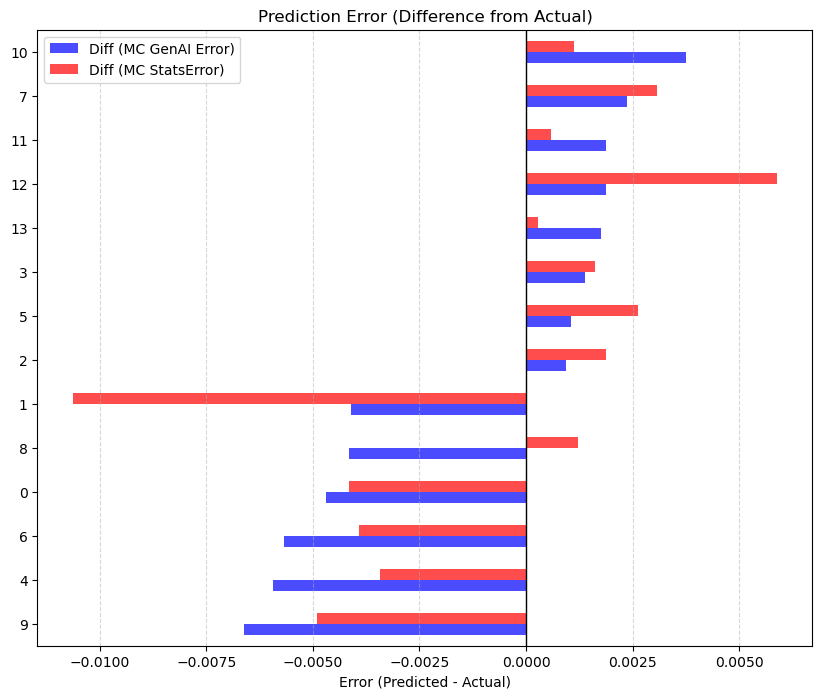

In [53]:
error_df = comparison[['Diff (MC GenAI Error)', 'Diff (MC StatsError)']]
error_df = error_df.sort_values(by='Diff (MC GenAI Error)')

plt.figure(figsize=(10, 8))
error_df.plot(kind='barh', figsize=(10, 8), color=['blue', 'red'], alpha=0.7)

plt.title("Prediction Error (Difference from Actual)")
plt.xlabel("Error (Predicted - Actual)")
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

<Axes: >

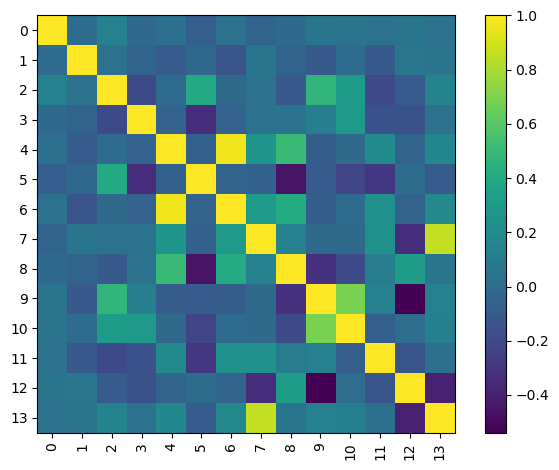

In [54]:
S_y_test = risk_models.sample_cov(y_test_df)
plotting.plot_covariance(S_y_test, plot_correlation=True)

<Axes: >

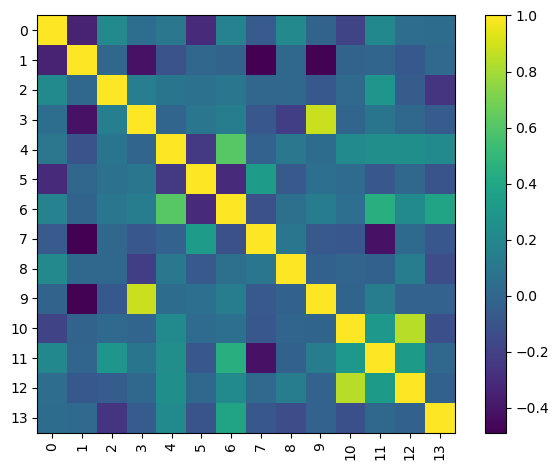

In [55]:
S_genai_mc = risk_models.sample_cov(genai_mc_df)
plotting.plot_covariance(S_genai_mc, plot_correlation=True)

<Axes: >

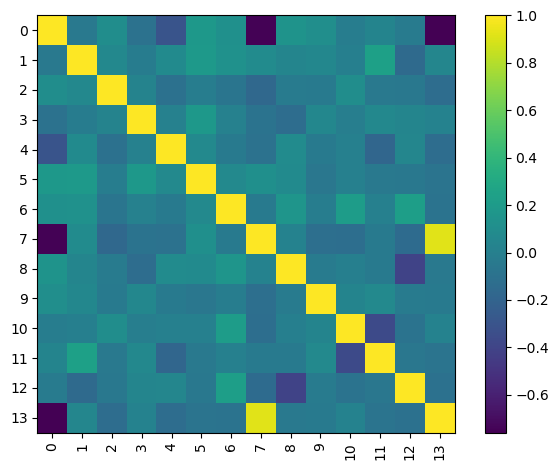

In [56]:
S_stats_mc = risk_models.sample_cov(stats_mc_df)
plotting.plot_covariance(S_stats_mc, plot_correlation=True)

### Portfolio Optimization

In [57]:
def optimize_portfolio(mu, S, name="Portfolio"):
    # 1. สร้าง Object
    # weight_bounds=(0, 1) คือห้าม Short sell (Long only)
    ef = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    
    # 2. สั่ง Optimize: เลือก Maximize Sharpe Ratio
    # (หรือจะใช้ ef.min_volatility() ถ้าอยากปลอดภัยสุดๆ)
    raw_weights = ef.max_sharpe()
    
    # 3. Clean Weights (ตัดตัวเลขทศนิยมยาวๆ ให้ดูง่าย)
    cleaned_weights = ef.clean_weights()
    
    # 4. โชว์ผลลัพธ์
    print(f"--- {name} Performance ---")
    ef.portfolio_performance(verbose=True)
    print("-" * 30)
    
    return cleaned_weights

In [58]:
mu_mc_genai

0    -0.000412
1     0.007273
2     0.001990
3     0.002668
4     0.001007
5    -0.000515
6     0.001233
7     0.000675
8     0.000279
9     0.001856
10    0.001341
11    0.000377
12    0.001086
13    0.001956
dtype: float32

In [59]:
weights_genai = optimize_portfolio(mu_mc_genai, S_genai_mc, "GenAI Allocation")
weights_stats = optimize_portfolio(mu_mc_stats, S_stats_mc, "Stats Allocation")
weights_gt = optimize_portfolio(mu_y, S_y_test, "Ground Truth Allocation")

--- GenAI Allocation Performance ---
Expected annual return: 0.6%
Annual volatility: 705.5%
Sharpe Ratio: 0.00
------------------------------
--- Stats Allocation Performance ---
Expected annual return: 0.4%
Annual volatility: 1307.6%
Sharpe Ratio: 0.00
------------------------------
--- Ground Truth Allocation Performance ---
Expected annual return: 0.7%
Annual volatility: 3099.8%
Sharpe Ratio: 0.00
------------------------------


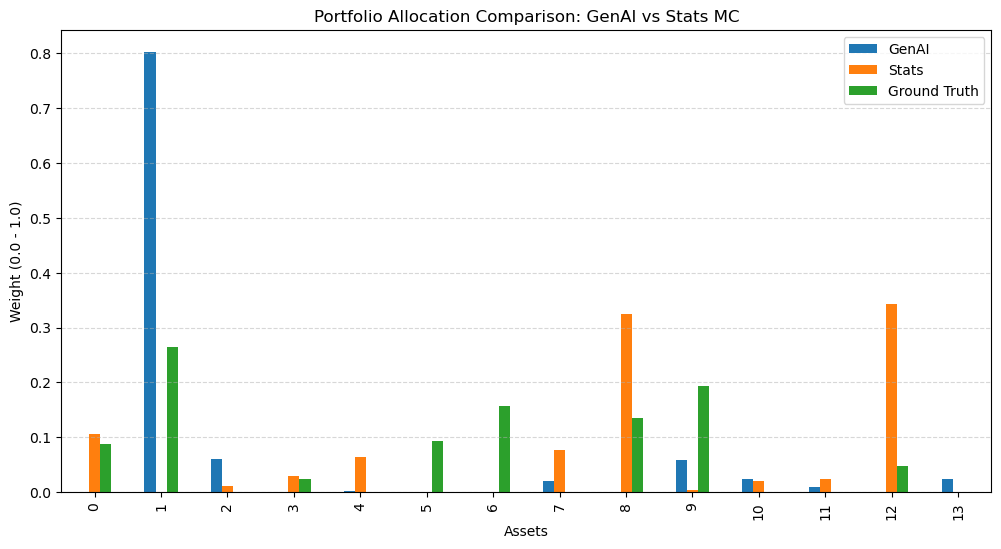

In [60]:
df_weights = pd.DataFrame({
    'GenAI': weights_genai,
    'Stats': weights_stats,
    'Ground Truth': weights_gt,
})

# Plot Bar Chart เปรียบเทียบสัดส่วนการถือหุ้น
df_weights.plot(kind='bar', figsize=(12, 6))
plt.title("Portfolio Allocation Comparison: GenAI vs Stats MC")
plt.ylabel("Weight (0.0 - 1.0)")
plt.xlabel("Assets")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2025-12-30   2025-12-30
End Period                 2026-01-22   2026-01-22
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          5.29%        26.62%
CAGR﹪                     71.88%       1092.2%

Sharpe                     2.89         6.76
Prob. Sharpe Ratio         81.42%       97.66%
Smart Sharpe               2.62         6.14
Sortino                    4.96         13.32
Smart Sortino              4.5          12.1
Sortino/√2                 3.51         9.42
Smart Sortino/√2           3.18         8.56
Omega                      1.68         2.81

Max Drawdown               -2.91%       -4.98%
Max DD Date                2026-01-01   2

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2025-12-30,2026-01-01,2026-01-03,5,-4.984700,-3.879452
2,2026-01-18,2026-01-18,2026-01-21,4,-3.935603,-0.936619
3,2026-01-16,2026-01-16,2026-01-16,1,-1.950265,NaN
4,2026-01-13,2026-01-13,2026-01-13,1,-1.729979,NaN
5,2026-01-05,2026-01-05,2026-01-06,2,-0.797779,-0.549108


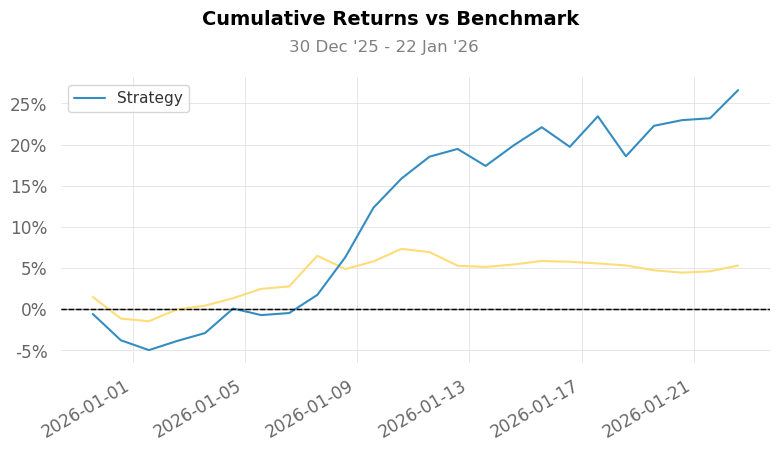

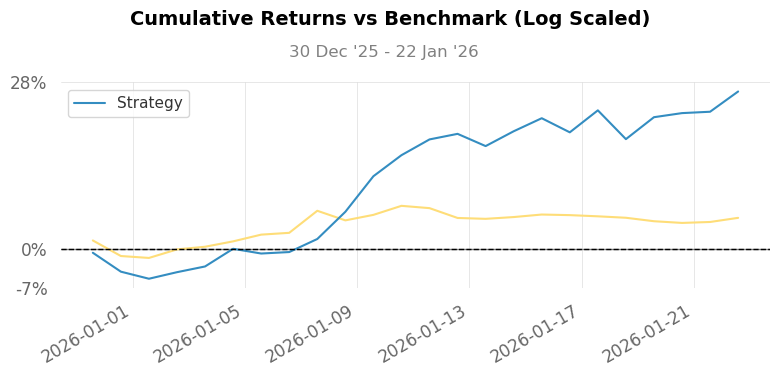

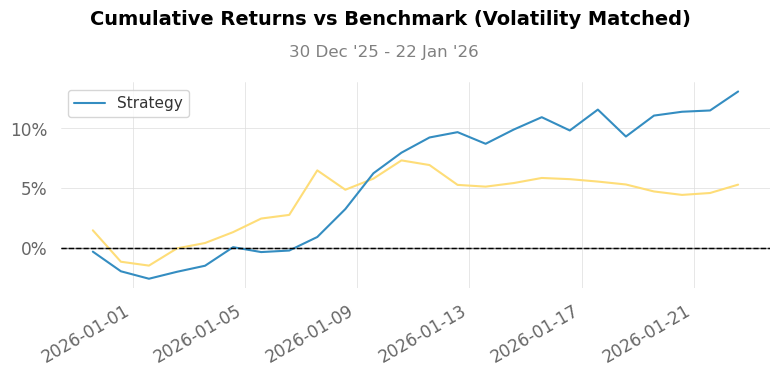

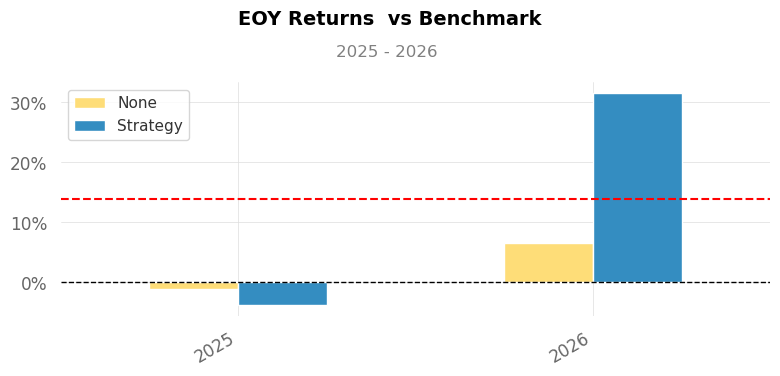

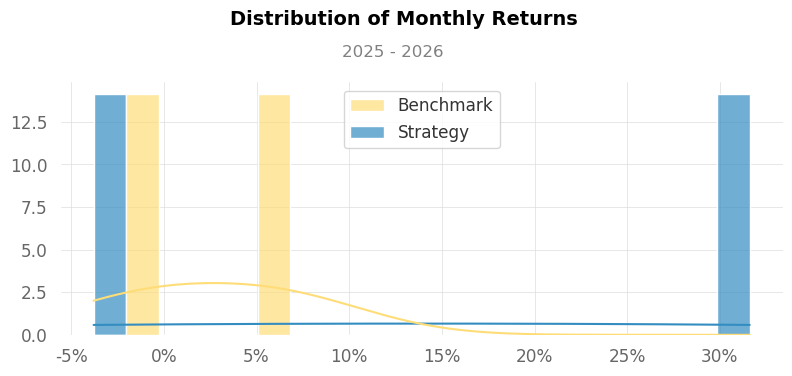

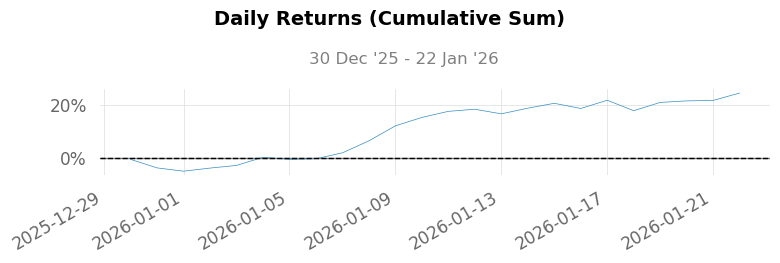

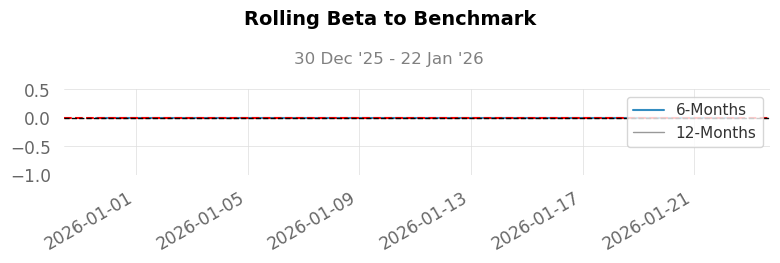

IndexError: index 0 is out of bounds for axis 0 with size 0

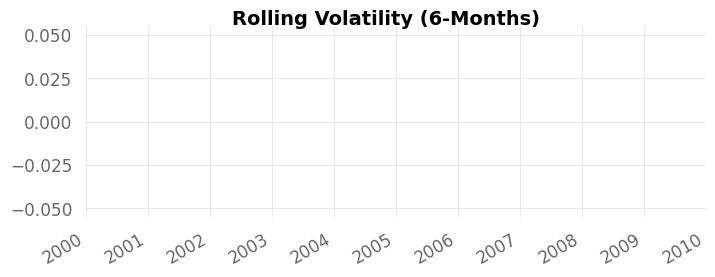

In [63]:
import quantstats as qs

y_real_simple = np.exp(y_test_df) - 1

# 2. ฟังก์ชันช่วยคำนวณ Portfolio Return รายวัน
def get_port_returns(weights_dict, real_returns):
    # แปลง dict weights เป็น array ที่เรียงตาม column
    w = np.array([weights_dict[col] for col in real_returns.columns])
    # คำนวณ (Returns * Weights) และรวมเป็นรายวัน
    return (real_returns * w).sum(axis=1)

# 3. คำนวณ Performance ของแต่ละค่ายบน "โลกจริง"
port_genai = get_port_returns(weights_genai, y_real_simple)
port_stats = get_port_returns(weights_stats, y_real_simple)
port_gt    = get_port_returns(weights_gt, y_real_simple) # พอร์ตเทพเจ้ารู้อนาคต

# 4. ใส่ Index วันที่เพื่อให้ QuantStats ทำงานได้
date_index = pd.date_range(end=pd.Timestamp.today(), periods=len(y_real_simple), freq='D')
port_genai.index = port_stats.index = port_gt.index = date_index

# 5. การเรียกใช้ QuantStats Report
# เทียบ GenAI (กลยุทธ์เรา) กับ Stats (Benchmark)
# หรือจะเทียบกับ Ground Truth เพื่อดูว่าเราห่างไกลจากความเพอร์เฟกต์แค่ไหน
qs.reports.full(port_genai, 
                benchmark=port_stats, 
                output=f'genai_mc_mean_vs_stats_mc_mean_epochs-{cfg.epochs}_sims-{cfg.num_sims}_steps-{cfg.steps_to_sim}.html',
                title='GenAI MC mean vs Stats MC mean')

In [64]:
qs.reports.html(port_genai, 
                benchmark=port_stats, 
                output=f'genai_mc_mean_vs_stats_mc_mean_epochs-{cfg.epochs}_sims-{cfg.num_sims}_steps-{cfg.steps_to_sim}.html',
                title='GenAI MC mean vs Stats MC mean')

# Data Stats (Portfolio optimization) by PyPortfolioOpt lib
ref: https://medium.com/qunt-i-love-u/python-library-%E0%B8%97%E0%B8%B5%E0%B9%88%E0%B9%80%E0%B8%81%E0%B8%B4%E0%B8%94%E0%B8%A1%E0%B8%B2%E0%B9%80%E0%B8%9E%E0%B8%B7%E0%B9%88%E0%B8%AD%E0%B8%97%E0%B8%B3-portfolio-optimization-b07398e2e228

In [ ]:
key = "Close"
gt_sampling = basket.data.xs(key=key,level=1, axis=1)
gt_sampling.head(5)

In [ ]:
gt_sampling_cov = risk_models.sample_cov(gt_sampling)
plotting.plot_covariance(gt_sampling_cov, plot_correlation=True)
plt.show()

### Exponential covariance

In [ ]:
gt_sampling_exp_cov = risk_models.exp_cov(gt_sampling)
plotting.plot_covariance(gt_sampling_cov, plot_correlation=True)
plotting.plot_covariance(gt_sampling_exp_cov, plot_correlation=True)
plt.show()

### We applied both shrinkage methods to compare their results.

In [ ]:
gt_sampling_cov_shrinkage = risk_models.CovarianceShrinkage(gt_sampling).ledoit_wolf()
plotting.plot_covariance(gt_sampling_cov, plot_correlation=True)
plotting.plot_covariance(gt_sampling_cov_shrinkage, plot_correlation=True)
plt.show()